In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Crop_recommendation.csv")

In [4]:
print(":---: Random 5 Rows :---:\n")
df.sample(5)

:---: Random 5 Rows :---:



,N,P,K,temperature,humidity,ph,rainfall,label
960,1,27,36,23.985988,93.342366,5.684995,104.991282,pomegranate
251,44,74,85,20.186494,19.637200,7.150681,78.260396,chickpea
1905,126,50,19,24.694571,81.735888,6.628723,78.584944,cotton
1372,90,14,52,24.847408,89.204546,6.391858,59.679272,watermelon
698,23,45,23,28.776535,86.691340,6.983130,56.124432,mungbean


In [5]:
# Let's establish exactly what NPK is, because it is the core of your whole project. N, P, and K stand for:

# N (Nitrogen): Helps plants grow leaves and stay green.

# P (Phosphorus): Helps plants build strong roots and flowers.

# K (Potassium): Helps the plant fight disease and grow healthy crop yields.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
# Unique Crops & Unique Vareities

print("--- Unique Crops ---")
print(df["label"].unique())

--- Unique Crops ---
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


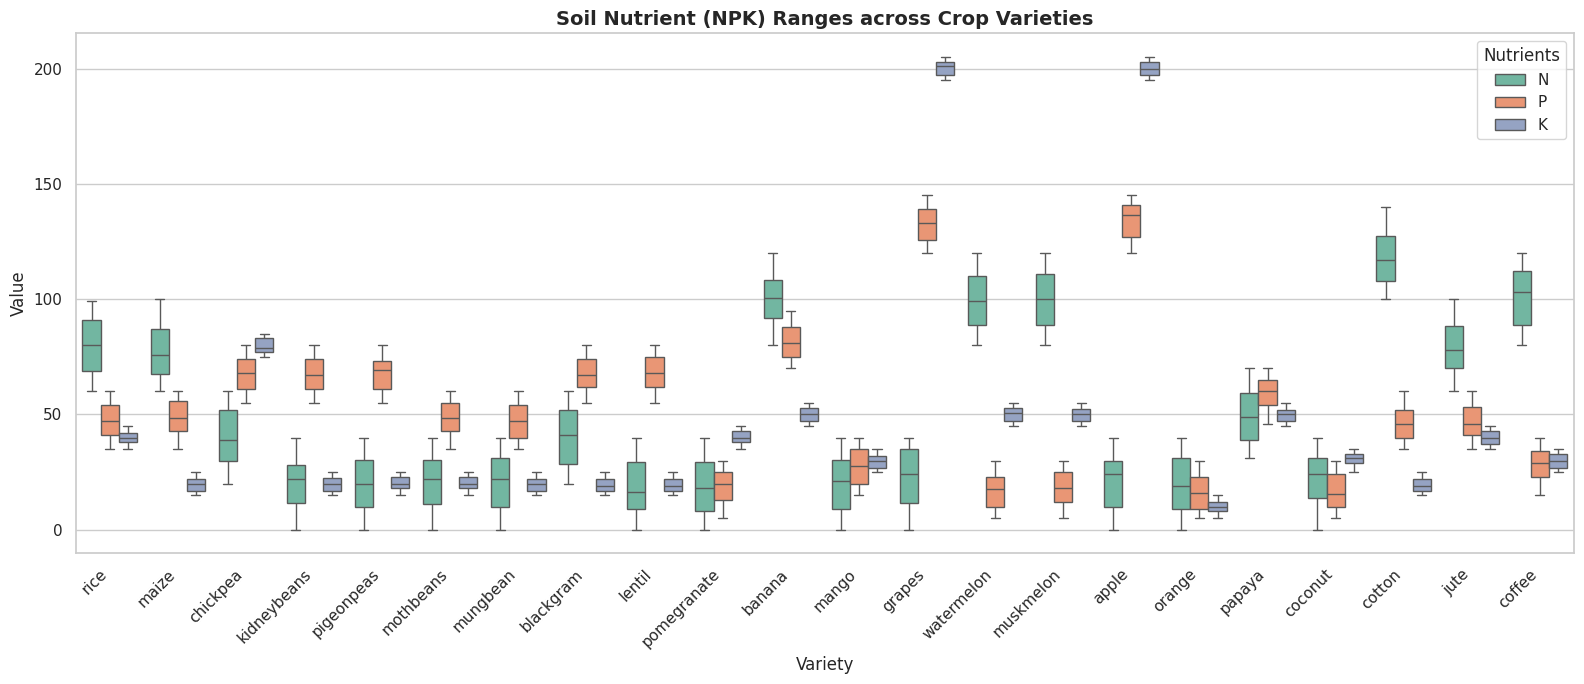

In [9]:
sns.set_theme(style="whitegrid")

melted_npk = pd.melt(df, id_vars=["label"], value_vars=["N", "P", "K"], var_name="Nutrients", value_name="Value")

plt.figure(figsize=(16, 7))
sns.boxplot(data = melted_npk, x = "label", y = "Value", hue = "Nutrients", palette = "Set2")

plt.title("Soil Nutrient (NPK) Ranges across Crop Varieties", fontsize=14, fontweight='bold')
plt.xlabel("Variety", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Sensor Validation: If the box heights and positions are completely different for each
# crop variety, it indicates that your NPK sensor data is incredibly valuable and will
# easily help your XGBoost model tell the crops apart.

# Overlaps: If two different crop varieties have boxes that sit at the exact same height
# and location, it indicates that NPK data alone cannot distinguish them. Your model
# will have to rely heavily on your other columns (like Temperature or pH) to make the right choice.



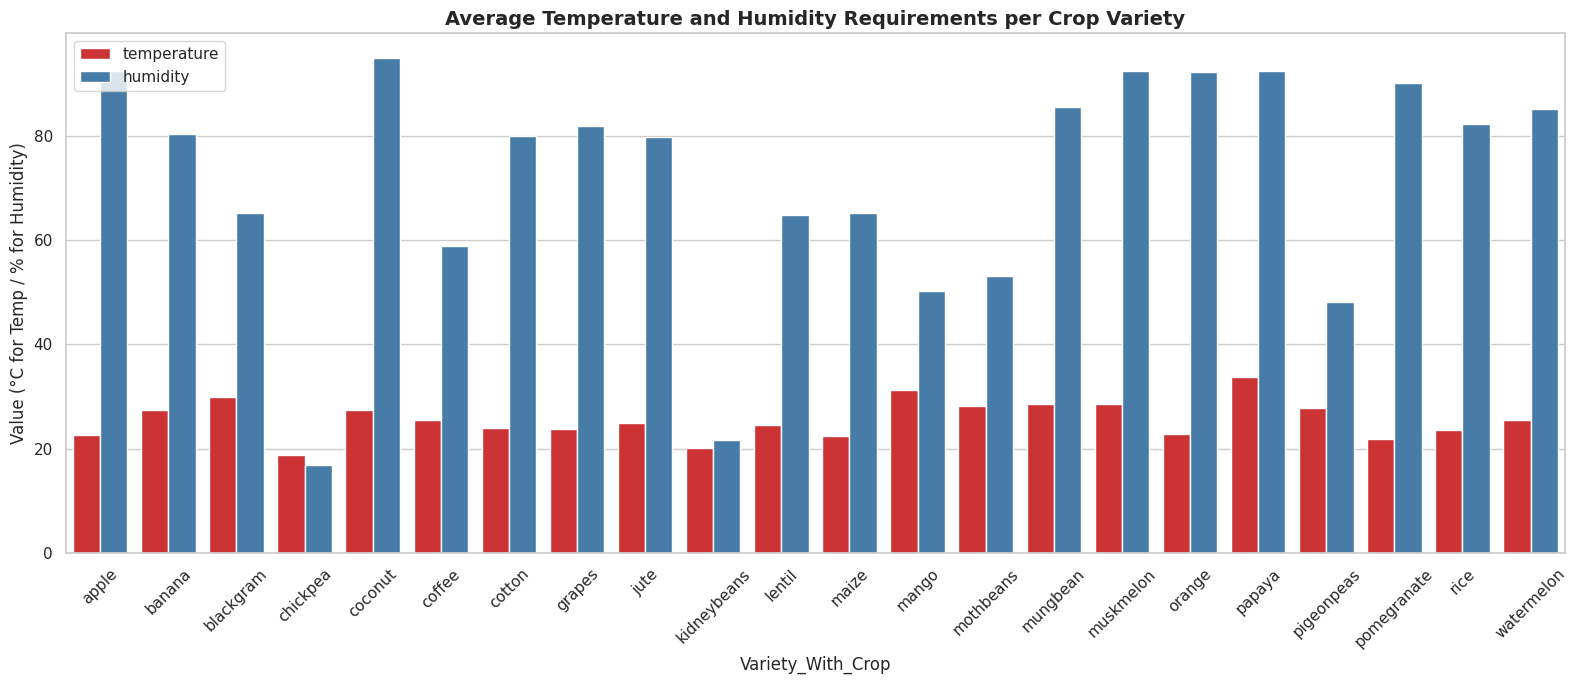

In [10]:
grouped = df.groupby("label")[["temperature", "humidity"]].agg("mean").reset_index()
melted = pd.melt(grouped, id_vars="label", value_vars=["temperature","humidity"], var_name="Climate Metrics", value_name="Avg Temperature & Humidity")

plt.figure(figsize=(16, 7))
sns.barplot(data=melted, x="label", y="Avg Temperature & Humidity", hue="Climate Metrics", palette="Set1")
plt.title("Average Temperature and Humidity Requirements per Crop Variety", fontsize=14, fontweight='bold')
plt.xlabel("Variety_With_Crop", fontsize=12)
plt.ylabel("Value (°C for Temp / % for Humidity)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

# Climate Segmentation: By calculating the mean (average), we can see which crop varieties
# belong to high-temperature/high-humidity climates (like tropical crops) versus low-temperature
# zones (like winter crops). This helps verify that our Weather API inputs provide a distinct,
# clear signal for the model.

# Seasonal Boundaries: Large gaps between the temperature/humidity bars of different crops
# represent clear seasonal shifts, proving that the model can easily use weather data to
# filter out incorrect seasonal varieties.


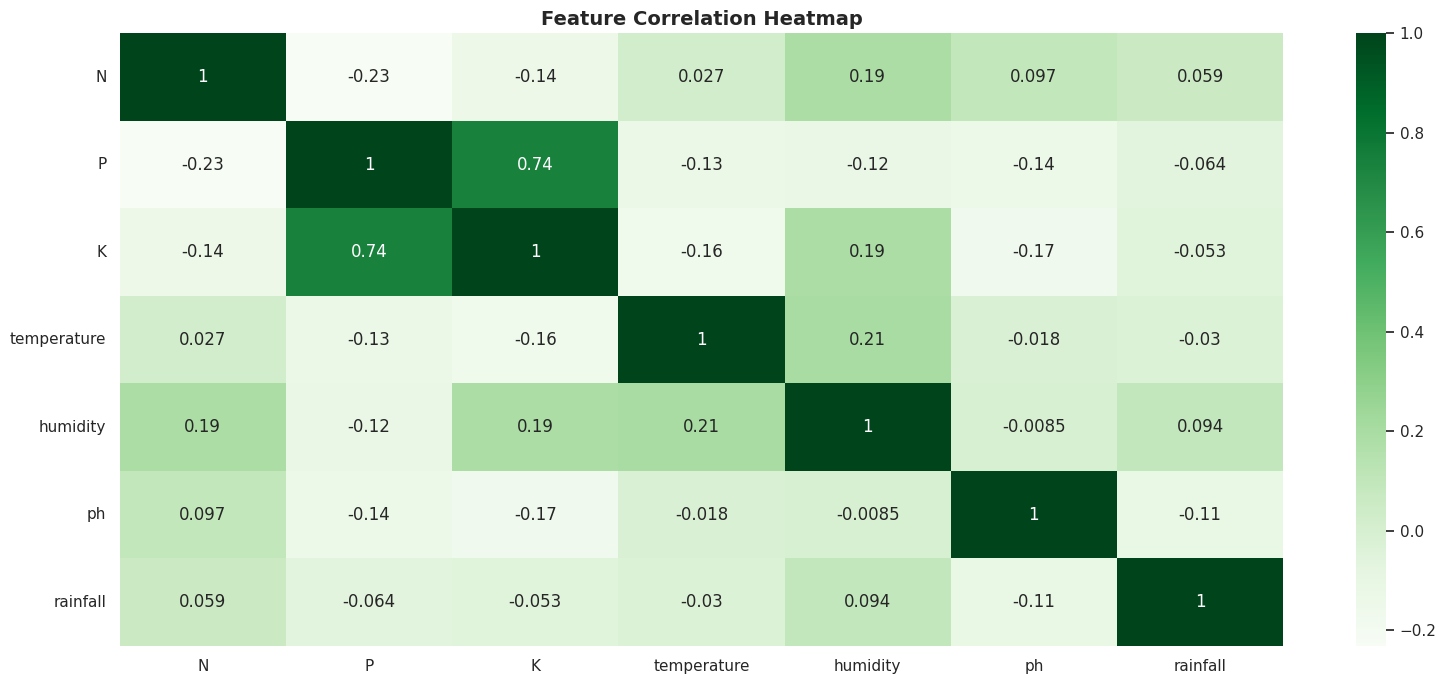

In [11]:
plt.figure(figsize=(16, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Greens")
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Interaction: The correlation heatmap quantifies the linear relationships
# between numerical features. This helps us spot multicollinearity (where two features
# provide identical information), allowing us to ensure our input features are
# independent and structurally sound for tree-based splitting.

# Sensor Integrity: If any unexpected high correlations appear (e.g., between completely
# unrelated soil metrics), it could signal data collection artifacts or bias that might
# skew feature importance scores in XGBoost.

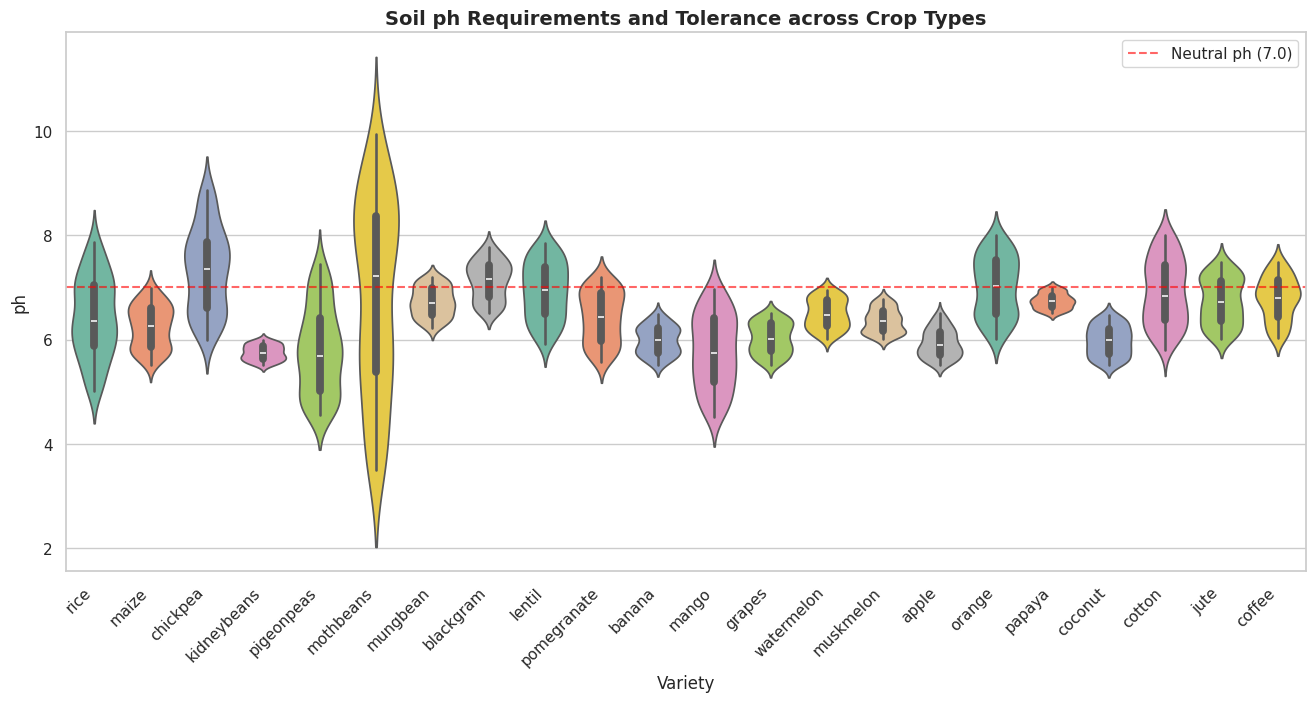

In [12]:
plt.figure(figsize=(16, 7))
sns.violinplot(df, x='label', y="ph", palette="Set2", hue="label")
plt.axhline(y=7.0, color="red", linestyle="--", alpha=0.6, label="Neutral ph (7.0)")

plt.title("Soil ph Requirements and Tolerance across Crop Types", fontsize=14, fontweight='bold')
plt.xlabel("Variety", fontsize=12)
plt.ylabel("ph", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.show()

# Soil Chemistry Validation: The pH plot illustrates the specific acidity and alkalinity
# limits required by each crop type. This directly validates the necessity of the physical
# pH sensor probe in our IoT architecture, as soil pH dictates nutrient availability.

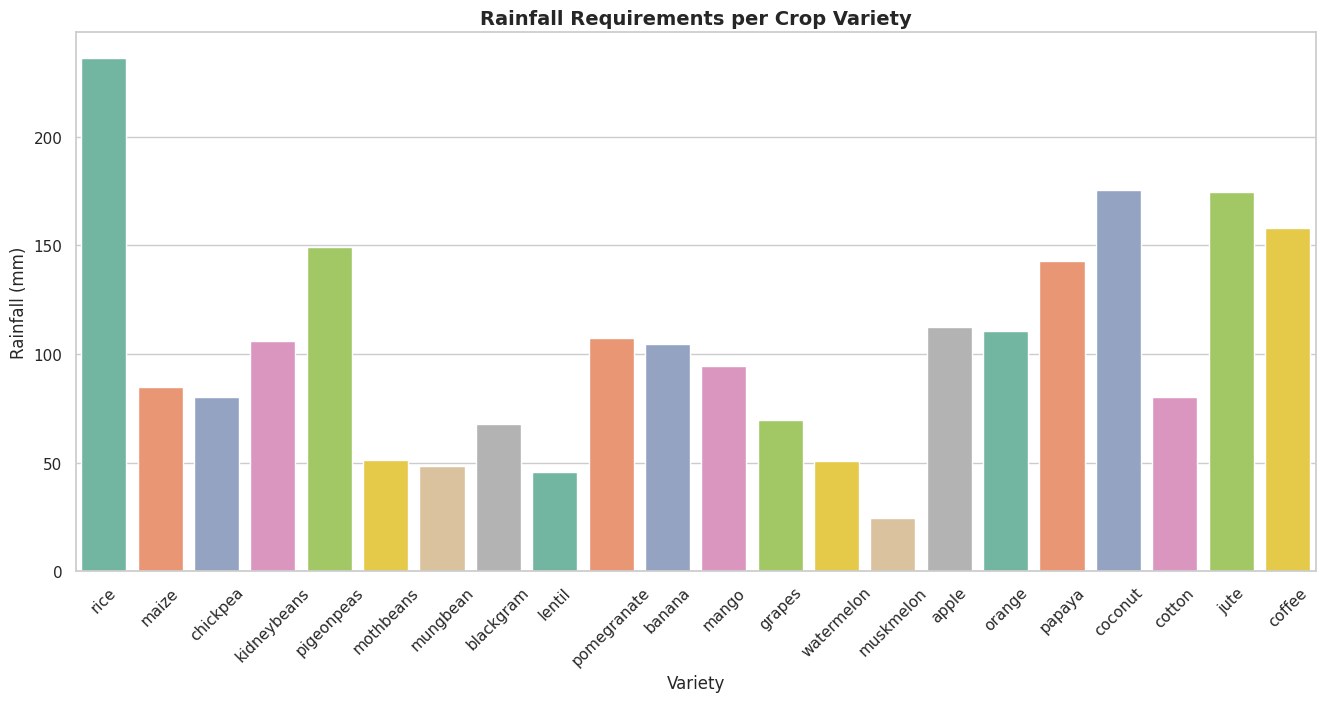

In [13]:
plt.figure(figsize=(16, 7))
sns.barplot(df, x="label", y="rainfall", errorbar=None, palette="Set2", hue="label")
plt.title("Rainfall Requirements per Crop Variety", fontsize=14, fontweight='bold')
plt.xlabel("Variety", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Water Threshold Validation: This analysis maps out the specific rainfall limits
# required by different crops. This directly validates why our architecture connects
# to a Weather API, as macro-climate water availability is a primary separator for
# high-water crops (like Rice) versus low-water crops (like Melons).

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
x = df.drop("label", axis=1)
y = df['label']

lb = LabelEncoder()
y = lb.fit_transform(y)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model)
])

pipeline.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [19]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = pipeline.predict(x_test)
base_accuracy = accuracy_score(y_test, y_pred)
print(f"Base Accuracy: {base_accuracy * 100:.2f}%\n")


print(classification_report(y_test, y_pred, target_names = lb.classes_))


Base Accuracy: 98.86%

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.85      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.91      1.00      0.95        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
    

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, x, y, cv=5, scoring="accuracy")

for idx, score in enumerate(cv_scores, 1):
  print(f"Fold {idx} Accuracy: {score * 100:.2f}%")

Fold 1 Accuracy: 99.09%
Fold 2 Accuracy: 99.09%
Fold 3 Accuracy: 99.77%
Fold 4 Accuracy: 99.55%
Fold 5 Accuracy: 99.32%


In [21]:
import pickle

# 1. Save the trained ML Pipeline (handles scaling + XGBoost)
with open('crop_pipeline.pkl', 'wb') as model_file:
    pickle.dump(pipeline, model_file)

# 2. Save the fitted Label Encoder mapping (handles number-to-text conversion)
with open('label_encoder.pkl', 'wb') as encoder_file:
    pickle.dump(lb, encoder_file)

print("Successfully generated 'crop_pipeline.pkl' and 'label_encoder.pkl' on the server!")

Successfully generated 'crop_pipeline.pkl' and 'label_encoder.pkl' on the server!
